In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# Loading raw processed data
train_df = pd.read_csv('data/processed/train.csv')
val_df   = pd.read_csv('data/processed/val.csv')
test_df  = pd.read_csv('data/processed/test.csv')

feat_cols = [f'f{i}' for i in range(1, 137)]

print(f'Train : {len(train_df):,} rows | {train_df["qid"].nunique():,} queries')
print(f'Val   : {len(val_df):,} rows | {val_df["qid"].nunique():,} queries')
print(f'Test  : {len(test_df):,} rows | {test_df["qid"].nunique():,} queries')

Train : 723,412 rows | 6,000 queries
Val   : 235,259 rows | 2,000 queries
Test  : 241,521 rows | 2,000 queries


### Feature Cleaning — Clipping Outliers

> **Critical rule:** percentile bounds are computed on **train only**, then applied
> to val and test. This prevents data leakage — val/test stats must never
> influence the transformation.

In [3]:
# Computing clip bounds on train only
clip_lower = train_df[feat_cols].quantile(0.01)
clip_upper = train_df[feat_cols].quantile(0.99)

# Applying to all splits
def clip_features(df, lower, upper):
    df = df.copy()
    df[feat_cols] = df[feat_cols].clip(lower=lower, upper=upper, axis=1)
    return df

train_clipped = clip_features(train_df, clip_lower, clip_upper)
val_clipped   = clip_features(val_df,   clip_lower, clip_upper)
test_clipped  = clip_features(test_df,  clip_lower, clip_upper)

# max values should now be at or below the 99th percentile
max_after = train_clipped[feat_cols].max().max()
max_before = train_df[feat_cols].max().max()
print(f'Max feature value before clipping: {max_before:,.0f}')
print(f'Max feature value after clipping: {max_after:,.4f}')

Max feature value before clipping: 980,000,001
Max feature value after clipping: 324,107.0000


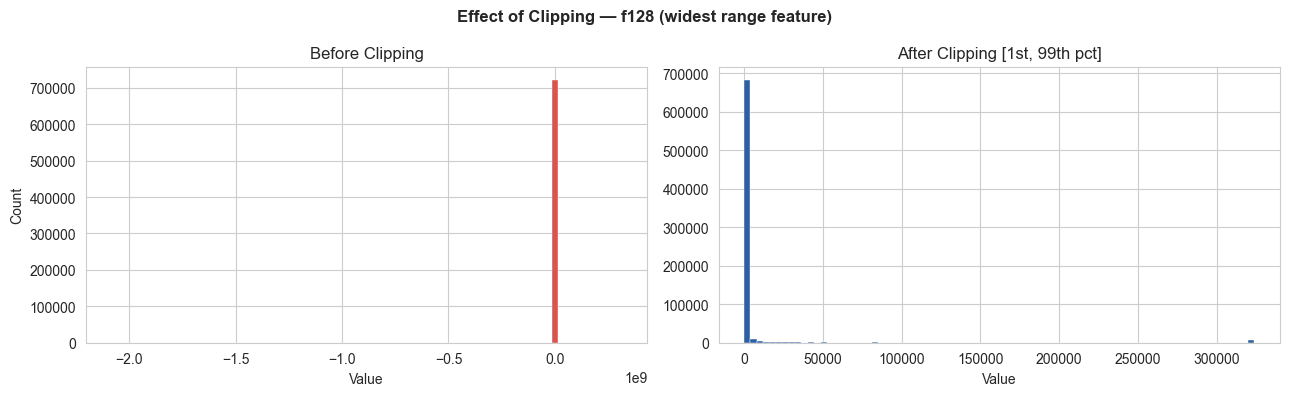

In [4]:
# Visualising effect of clipping on a high-outlier feature
# Picking the feature with the widest original range
widest_feat = (train_df[feat_cols].max() - train_df[feat_cols].min()).idxmax()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Effect of Clipping — {widest_feat} (widest range feature)',
             fontweight='bold')

axes[0].hist(train_df[widest_feat], bins=80, color='#D9534F', edgecolor='white', lw=0.3)
axes[0].set_title('Before Clipping')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

axes[1].hist(train_clipped[widest_feat], bins=80, color='#2E5FA3', edgecolor='white', lw=0.3)
axes[1].set_title('After Clipping [1st, 99th pct]')
axes[1].set_xlabel('Value')

plt.tight_layout()
plt.savefig('outputs/plots/02_clipping_effect.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Scaling using StandardScaler

In [5]:
# Fitting scaler on clipped train features only
scaler = StandardScaler()
scaler.fit(train_clipped[feat_cols])

def scale_df(df, scaler, feat_cols):
    df = df.copy()
    df[feat_cols] = scaler.transform(df[feat_cols])
    return df

train_scaled = scale_df(train_clipped, scaler, feat_cols)
val_scaled   = scale_df(val_clipped,   scaler, feat_cols)
test_scaled  = scale_df(test_clipped,  scaler, feat_cols)

# train features should have mean ~0 and std ~1
train_means = train_scaled[feat_cols].mean()
train_stds  = train_scaled[feat_cols].std()
print(f'Post-scaling train feature means: min={train_means.min():.4f}, max={train_means.max():.4f}')
print(f'Post-scaling train feature stds : min={train_stds.min():.4f}, max={train_stds.max():.4f}')

Post-scaling train feature means: min=-0.0000, max=0.0000
Post-scaling train feature stds : min=1.0000, max=1.0000


### Feature Engineering — New Features

> We engineer 4 categories of new features:
> 1. **Cross-zone aggregations** — max/mean BM25 across all 5 zones
> 2. **Zone dominance** — which zone has the highest score (argmax)
> 3. **Interaction features** — BM25 × PageRank, TF-IDF × QualityScore
> 4. **Query-level normalisation** — feature value relative to query mean
>
> **Why these specifically?**
> - Cross-zone max captures the strongest matching signal across any zone
> - Zone dominance tells the model *where* the match is strongest
> - Interactions capture that authority (PageRank) × relevance (BM25) is
>   stronger than either alone — a high-authority page about the query topic
> - Query-level normalisation helps neural models because absolute scores
>   vary wildly across queries; relative scores are more stable

In [6]:
# Feature group definitions
feature_groups = {
    'covered_qt_num' : [f'f{i}' for i in range(1,  6)],
    'covered_qt_rat' : [f'f{i}' for i in range(6,  11)],
    'stream_len'     : [f'f{i}' for i in range(11, 16)],
    'idf'            : [f'f{i}' for i in range(16, 21)],
    'sum_tf'         : [f'f{i}' for i in range(21, 26)],
    'min_tf'         : [f'f{i}' for i in range(26, 31)],
    'max_tf'         : [f'f{i}' for i in range(31, 36)],
    'mean_tf'        : [f'f{i}' for i in range(36, 41)],
    'var_tf'         : [f'f{i}' for i in range(41, 46)],
    'sum_tfidf'      : [f'f{i}' for i in range(46, 51)],
    'min_tfidf'      : [f'f{i}' for i in range(51, 56)],
    'max_tfidf'      : [f'f{i}' for i in range(56, 61)],
    'mean_tfidf'     : [f'f{i}' for i in range(61, 66)],
    'var_tfidf'      : [f'f{i}' for i in range(66, 71)],
    'bm25'           : [f'f{i}' for i in range(71, 76)],
    'lmir_abs'       : [f'f{i}' for i in range(76, 81)],
    'lmir_dir'       : [f'f{i}' for i in range(81, 86)],
    'lmir_jm'        : [f'f{i}' for i in range(86, 91)],
    'qd_sim'         : [f'f{i}' for i in range(99, 104)],
    'qd_sim2'        : [f'f{i}' for i in range(104, 109)],
    'boolean_model'  : [f'f{i}' for i in range(109, 114)],
    'vector_space'   : [f'f{i}' for i in range(114, 119)],
    'bm25_variant'   : [f'f{i}' for i in range(119, 124)],
    'lmir_variant'   : [f'f{i}' for i in range(124, 129)],
}

# Zone labels for argmax features
zone_names = ['body', 'anchor', 'title', 'url', 'doc']

print(f'Feature groups defined: {len(feature_groups)}')
print('Ready to engineer new features.')

Feature groups defined: 24
Ready to engineer new features.


In [22]:
def engineer_features(df, clip_lower=None, clip_upper=None):
    """
    Input df should already be clipped (unscaled) — we clip
    raw values inside this function for the query-norm features.
    Returns df with additional columns for each engineered feature.
    """
    df = df.copy()
    new_feat_names = []

    #Category 1: Cross-zone aggregations
    #For each 5-zone group: max, mean, and std across zones
    #Rationale: compress 5 correlated features into 3 that capture
    #the peak signal, average signal, and spread of signal
    agg_groups = ['bm25', 'sum_tfidf', 'mean_tfidf', 'lmir_abs',
                  'lmir_dir', 'lmir_jm', 'sum_tf', 'qd_sim']

    for grp in agg_groups:
        cols = feature_groups[grp]
        df[f'{grp}_zone_max']  = df[cols].max(axis=1)
        df[f'{grp}_zone_mean'] = df[cols].mean(axis=1)
        df[f'{grp}_zone_std']  = df[cols].std(axis=1)
        new_feat_names += [f'{grp}_zone_max', f'{grp}_zone_mean', f'{grp}_zone_std']

    #Category 2: zone dominance (argmax)
    #Identifying Which zone has the highest BM25 / TF-IDF score
    #Rationale: a title match (zone 2) is qualitatively different
    #from a body match (zone 0)
    for grp in ['bm25', 'sum_tfidf']:
        cols = feature_groups[grp]
        df[f'{grp}_dominant_zone'] = df[cols].values.argmax(axis=1)  # 0-4
        new_feat_names.append(f'{grp}_dominant_zone')

    #Category 3: Interaction features
    #BM25 (whole doc) × PageRank: authority-weighted relevance
    #Rationale: a high-PageRank page that is also BM25-relevant
    #is a much stronger signal than either alone
    df['bm25_doc_x_pagerank']    = df['f75'] * df['f95']
    df['tfidf_doc_x_quality']    = df['f50'] * df['f97']
    df['bm25_title_x_pagerank']  = df['f73'] * df['f95']
    df['covered_ratio_x_bm25']   = df['f10'] * df['f75']  
    new_feat_names += [
        'bm25_doc_x_pagerank', 'tfidf_doc_x_quality',
        'bm25_title_x_pagerank', 'covered_ratio_x_bm25'
    ]

    #Category 4: Query-level normalisation
    #For each query: subtract query mean and divide by query std
    #Rationale: BM25=5.0 means different things for different queries
    #Query-normed score tells us how this doc compares to
    #other candidates for the same query.
    qnorm_groups = ['bm25', 'sum_tfidf', 'lmir_abs']
    qnorm_cols   = [feature_groups[g][-1] for g in qnorm_groups]  # whole-doc features

    for col in qnorm_cols:
        q_mean = df.groupby('qid')[col].transform('mean')
        q_std  = df.groupby('qid')[col].transform('std').replace(0, 1)  # avoid div/0
        df[f'{col}_qnorm'] = (df[col] - q_mean) / q_std
        new_feat_names.append(f'{col}_qnorm')

    return df, new_feat_names


#Applying to all splits
#Engineering on clipped (unscaled) data.
#The query-norm features need the original scale to be meaningful.
train_eng, new_feats = engineer_features(train_clipped)
val_eng,   _         = engineer_features(val_clipped)
test_eng,  _         = engineer_features(test_clipped)

all_feat_cols = feat_cols + new_feats

print(f'Original features : {len(feat_cols)}')
print(f'Engineered features: {len(new_feats)}')
print(f'Total features     : {len(all_feat_cols)}')
print(f'\nNew features added:')
for f in new_feats:
    print(f'{f}')

Original features : 136
Engineered features: 33
Total features     : 169

New features added:
bm25_zone_max
bm25_zone_mean
bm25_zone_std
sum_tfidf_zone_max
sum_tfidf_zone_mean
sum_tfidf_zone_std
mean_tfidf_zone_max
mean_tfidf_zone_mean
mean_tfidf_zone_std
lmir_abs_zone_max
lmir_abs_zone_mean
lmir_abs_zone_std
lmir_dir_zone_max
lmir_dir_zone_mean
lmir_dir_zone_std
lmir_jm_zone_max
lmir_jm_zone_mean
lmir_jm_zone_std
sum_tf_zone_max
sum_tf_zone_mean
sum_tf_zone_std
qd_sim_zone_max
qd_sim_zone_mean
qd_sim_zone_std
bm25_dominant_zone
sum_tfidf_dominant_zone
bm25_doc_x_pagerank
tfidf_doc_x_quality
bm25_title_x_pagerank
covered_ratio_x_bm25
f75_qnorm
f50_qnorm
f80_qnorm


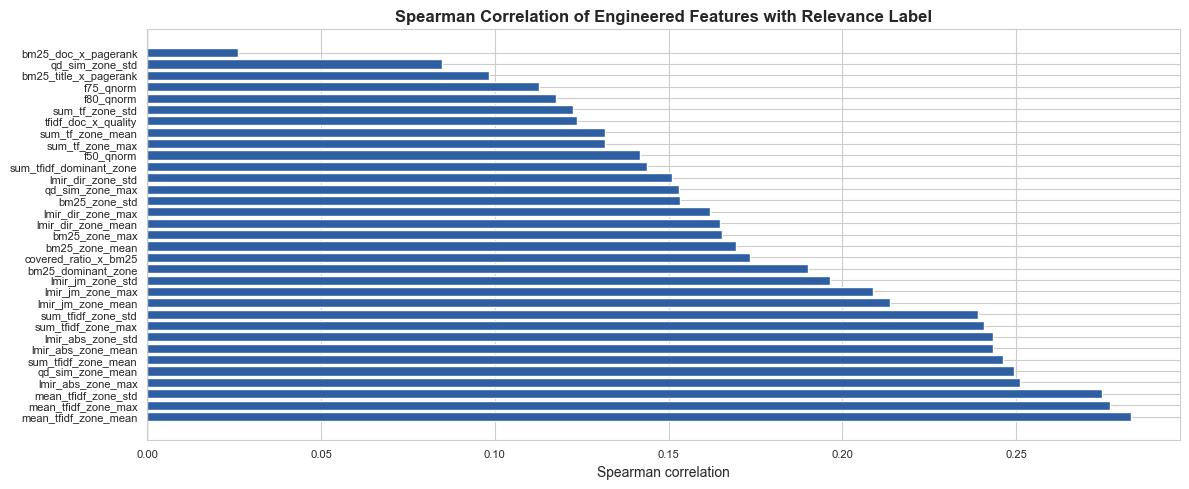

Top 5 engineered features by |correlation|:
mean_tfidf_zone_mean    0.283005
mean_tfidf_zone_max     0.277038
mean_tfidf_zone_std     0.274775
lmir_abs_zone_max       0.251069
qd_sim_zone_mean        0.249353


In [23]:
#Checking whether the engineered features correlate with label
#This acts as a great pre-training measure to see if our feature engg process is actually right
from scipy.stats import spearmanr

sample = train_eng.sample(50000, random_state=42)
eng_corrs = {}
for f in new_feats:
    corr, _ = spearmanr(sample[f], sample['label'])
    eng_corrs[f] = corr

eng_corr_series = pd.Series(eng_corrs).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2E5FA3' if v >= 0 else '#D9534F' for v in eng_corr_series]
ax.barh(eng_corr_series.index, eng_corr_series.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Spearman Correlation of Engineered Features with Relevance Label',
             fontweight='bold')
ax.set_xlabel('Spearman correlation')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('outputs/plots/02_engineered_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 engineered features by |correlation|:')
print(eng_corr_series.abs().nlargest(5).to_string())

### Feature Selection

> **Why select features at all?**
> - LightGBM handles 180 features easily — no selection needed
> - CNNs and LSTMs with 180 input dims are fine too, but redundant features
>   can add noise to gradients without adding signal
>
> We use **Mutual Information** (mutual_info_regression) to rank features.
> MI is better than Spearman correlation here because:
> - It captures non-linear relationships, not just monotonic ones
> - It's model-agnostic — doesn't assume any particular relationship shape

In [25]:
# Computing mutual information on a sample (MI is slow on full 723k rows)
sample = train_eng[all_feat_cols + ['label']].sample(50000, random_state=42)

mi_scores = mutual_info_regression(
    sample[all_feat_cols],
    sample['label'],
    random_state=42
)

mi_series = pd.Series(mi_scores, index=all_feat_cols).sort_values(ascending=False)

print(f'\nTop 20 features by Mutual Information:')
print(mi_series.head(20).to_string())
print(f'\nBottom 10 features by Mutual Information (potential drops):')
print(mi_series.tail(10).to_string())


Top 20 features by Mutual Information:
f19                    0.103390
f16                    0.099128
f20                    0.097685
f18                    0.094024
f17                    0.093809
f122                   0.087927
f112                   0.085921
f117                   0.085906
f119                   0.083034
f124                   0.082309
f114                   0.081704
f113                   0.075820
f123                   0.075781
f88                    0.072201
f118                   0.070176
f73                    0.064452
f83                    0.058805
f103                   0.056337
lmir_abs_zone_mean     0.052405
mean_tfidf_zone_std    0.052330

Bottom 10 features by Mutual Information (potential drops):
f77     0.001454
f13     0.001148
f14     0.001113
f1      0.000812
f66     0.000731
f67     0.000000
f57     0.000000
f42     0.000000
f69     0.000000
f135    0.000000


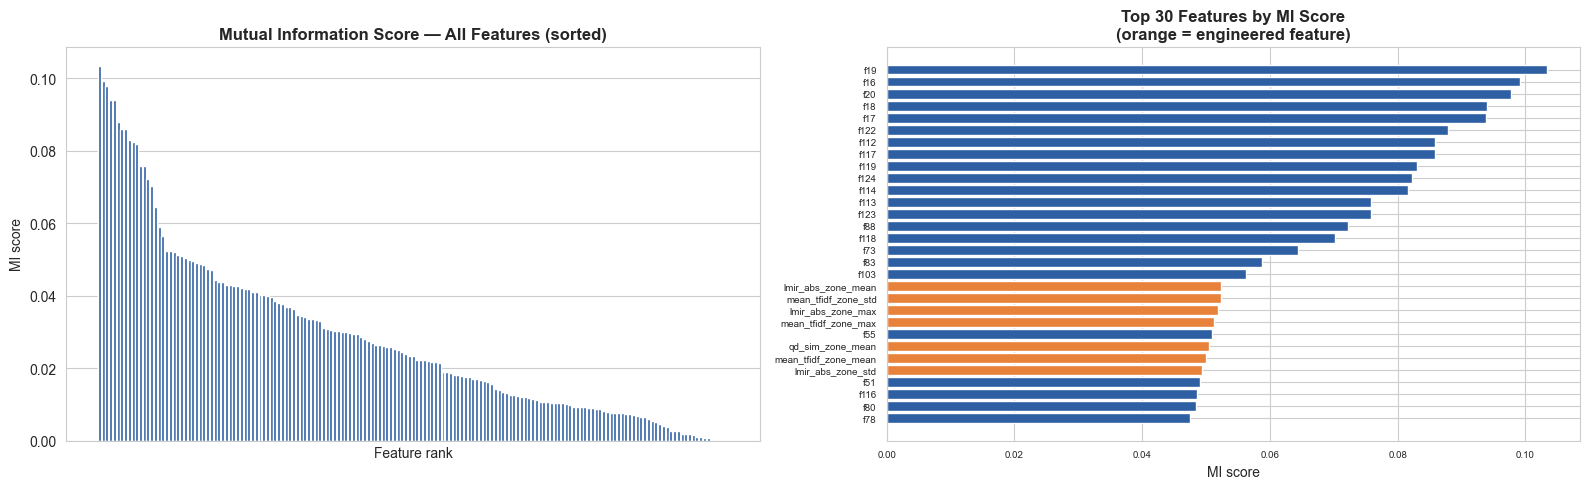

Engineered features in top 30 by MI: 7
  lmir_abs_zone_mean  (MI = 0.0524)
  mean_tfidf_zone_std  (MI = 0.0523)
  lmir_abs_zone_max  (MI = 0.0519)
  mean_tfidf_zone_max  (MI = 0.0513)
  qd_sim_zone_mean  (MI = 0.0504)
  mean_tfidf_zone_mean  (MI = 0.0499)
  lmir_abs_zone_std  (MI = 0.0494)


In [26]:
# Visualising MI scores
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: all features sorted by MI
axes[0].bar(range(len(mi_series)), mi_series.values,
            color='#2E5FA3', width=0.8)
axes[0].set_title('Mutual Information Score — All Features (sorted)',
                  fontweight='bold')
axes[0].set_xlabel('Feature rank')
axes[0].set_ylabel('MI score')
axes[0].set_xticks([])

# Right: top 30 features
top30 = mi_series.head(30)
colors = ['#E8813A' if f in new_feats else '#2E5FA3' for f in top30.index]
axes[1].barh(top30.index[::-1], top30.values[::-1], color=colors[::-1])
axes[1].set_title('Top 30 Features by MI Score\n(orange = engineered feature)',
                  fontweight='bold')
axes[1].set_xlabel('MI score')
axes[1].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('outputs/plots/02_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

# How many engineered features made the top 30
top30_eng = [f for f in mi_series.head(30).index if f in new_feats]
print(f'Engineered features in top 30 by MI: {len(top30_eng)}')
for f in top30_eng:
    print(f'  {f}  (MI = {mi_series[f]:.4f})')

In [27]:
# Selecting top-K features for neural models
# LightGBM will use all features (it handles redundancy well)
# Neural models: we'll use top 64 by MI score

K = 64
top_k_feats = mi_series.head(K).index.tolist()

print(f'Selected top {K} features for neural models:')
print(f'Raw features in top-{K} : {sum(1 for f in top_k_feats if f in feat_cols)}')
print(f'Engineered features in top-{K}: {sum(1 for f in top_k_feats if f in new_feats)}')

Selected top 64 features for neural models:
Raw features in top-64 : 47
Engineered features in top-64: 17


### Scaling Engineered Features for Neural Models

> The interaction and query-normalized features are on different scales from the
> original features. We fit a new scaler on all features (raw + engineered)
> for the neural model inputs.

In [28]:
# Scaling all engineered features for neural models
# Fitting on train only
scaler_neural = StandardScaler()
scaler_neural.fit(train_eng[top_k_feats])

def scale_neural(df, scaler, top_k_feats):
    df = df.copy()
    df[top_k_feats] = scaler.transform(df[top_k_feats])
    return df

train_neural = scale_neural(train_eng, scaler_neural, top_k_feats)
val_neural   = scale_neural(val_eng,   scaler_neural, top_k_feats)
test_neural  = scale_neural(test_eng,  scaler_neural, top_k_feats)

# Verification
means = train_neural[top_k_feats].mean()
stds  = train_neural[top_k_feats].std()
print(f'Neural feature means: min={means.min():.4f}, max={means.max():.4f}')
print(f'Neural feature stds : min={stds.min():.4f},  max={stds.max():.4f}')

Neural feature means: min=-0.0000, max=0.0000
Neural feature stds : min=1.0000,  max=1.0000


### Business KPI Baseline — Pre-Model
> KPIs we're tracking:

> NDCG@10: Quality of top-10 ranked results
> MRR: How far user scrolls to find first relevant result
> P@1: Is the single top result relevant (label ≥ 1)?
> Frustration rate: % of queries where top 3 are all label=0
> Hit@3 (label≥3): % of queries with a highly relevant doc in top 3

In [29]:
#Discounted Cumulative Gain at K
def dcg_at_k(labels, k=10):
    labels = np.array(labels[:k], dtype=float)
    if len(labels) == 0:
        return 0.0
    gains = 2 ** labels - 1
    discounts = np.log2(np.arange(2, len(labels) + 2))
    return (gains / discounts).sum()

#Normalised DCG at K
def ndcg_at_k(labels, k=10):
    ideal = sorted(labels, reverse=True)
    ideal_dcg = dcg_at_k(ideal, k)
    if ideal_dcg == 0:
        return 0.0
    return dcg_at_k(labels, k) / ideal_dcg

#Mean Reciprocal Rank — position of first relevant doc
def mrr(labels):
    for i, l in enumerate(labels):
        if l >= 1:
            return 1.0 / (i + 1)
    return 0.0

# To check if the top result relevant
def precision_at_1(labels):
    return 1.0 if (len(labels) > 0 and labels[0] >= 1) else 0.0

#Fraction of top-k that are label=0
def frustration_rate(labels, k=3):
    top = labels[:k]
    return 1.0 if all(l == 0 for l in top) else 0.0

#Does top-k contain at least one label ?
def hit_at_k_highly_relevant(labels, k=3):
    return 1.0 if any(l >= 3 for l in labels[:k]) else 0.0

def evaluate_ranking(df, score_col, k=10):
    """
    Given a DataFrame with qid, label, and a score column,
    ranking documents within each query by score and computing KPIs.
    """
    results = []
    for qid, group in df.groupby('qid'):
        ranked_labels = group.sort_values(score_col, ascending=False)['label'].tolist()
        results.append({
            'ndcg@10'            : ndcg_at_k(ranked_labels, k),
            'mrr'                : mrr(ranked_labels),
            'p@1'                : precision_at_1(ranked_labels),
            'frustration_rate'   : frustration_rate(ranked_labels, 3),
            'hit@3_highly_rel'   : hit_at_k_highly_relevant(ranked_labels, 3),
        })
    return pd.DataFrame(results).mean()

print('Evaluation functions defined.')

Evaluation functions defined.


In [30]:
import random

# Using test set for baseline evaluation
# 1. Random ranking baseline
np.random.seed(42)
test_eval = test_clipped[['qid', 'label', 'f75']].copy()  # f75 = BM25 whole doc
test_eval['random_score'] = np.random.random(len(test_eval))

random_kpis = evaluate_ranking(test_eval, 'random_score')

# 2. BM25 whole-doc ranking baseline (f75)
bm25_kpis = evaluate_ranking(test_eval, 'f75')

# Display baseline results
baseline_df = pd.DataFrame({
    'Random Ranking' : random_kpis,
    'BM25 (f75)'     : bm25_kpis,
}).T

print('Pre-Model Baseline KPIs — Test Set')
print(baseline_df.to_string())
print('\nThese are the numbers our models must beat.')
print('BM25 is the strongest single-feature baseline.')

Pre-Model Baseline KPIs — Test Set
                 ndcg@10       mrr     p@1  frustration_rate  hit@3_highly_rel
Random Ranking  0.184750  0.597324  0.4275            0.2715            0.0735
BM25 (f75)      0.229071  0.617214  0.4555            0.2620            0.0760

These are the numbers our models must beat.
BM25 is the strongest single-feature baseline.


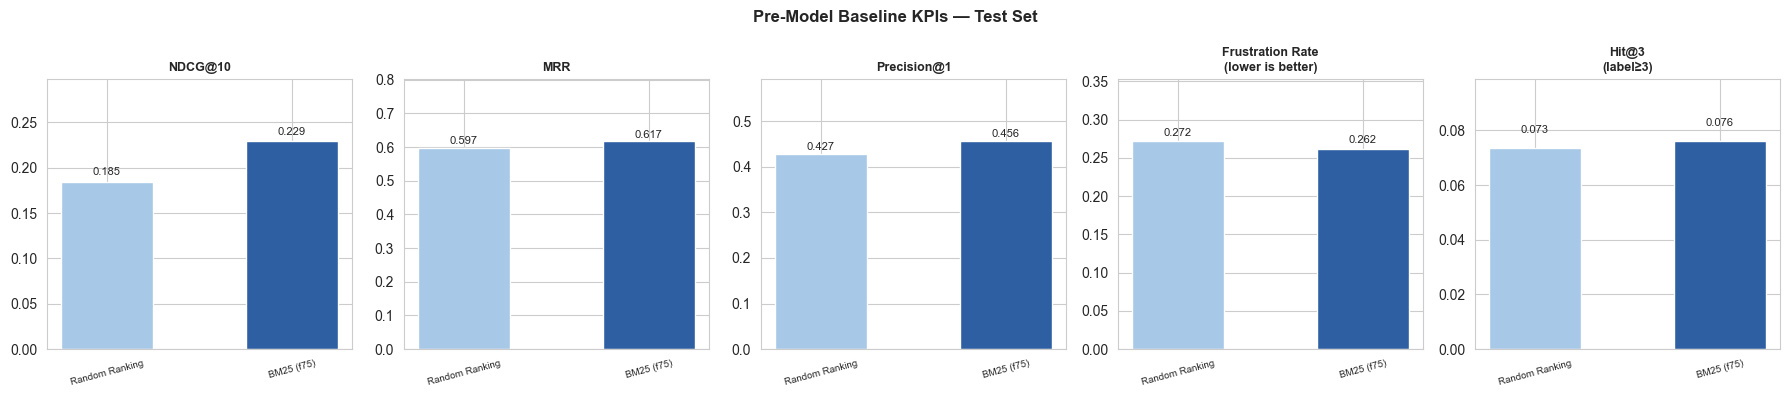


Business interpretation:
BM25 frustration rate  : 26.2% of queries
that many users see 3 irrelevant results in a row at the top.
Our models will aim to reduce this.


In [31]:
# Visualising baseline KPIs
kpi_labels = {
    'ndcg@10'          : 'NDCG@10',
    'mrr'              : 'MRR',
    'p@1'              : 'Precision@1',
    'frustration_rate' : 'Frustration Rate\n(lower is better)',
    'hit@3_highly_rel' : 'Hit@3\n(label≥3)',
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Pre-Model Baseline KPIs — Test Set', fontweight='bold', fontsize=12)

palette = ['#A8C8E8', '#2E5FA3']
models  = ['Random Ranking', 'BM25 (f75)']

for ax, (kpi, label) in zip(axes, kpi_labels.items()):
    vals = [baseline_df.loc[m, kpi] for m in models]
    bars = ax.bar(models, vals, color=palette, edgecolor='white', width=0.5)
    ax.set_title(label, fontweight='bold', fontsize=9)
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=15, fontsize=7)

plt.tight_layout()
plt.savefig('outputs/plots/02_baseline_kpis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nBusiness interpretation:')
print(f'BM25 frustration rate  : {bm25_kpis["frustration_rate"]:.1%} of queries')
print(f'that many users see 3 irrelevant results in a row at the top.')
print(f'Our models will aim to reduce this.')

### Saveing Processed Datasets

> We save two versions:
>  - LightGBM version: clipped + all engineered features, unscaled
>  - Neural version: clipped + top-64 features, scaled

In [32]:
import pickle, json

#LightGBM datasets (unscaled, all features)
lgbm_cols = ['label', 'qid'] + all_feat_cols
train_eng[lgbm_cols].to_csv('data/processed/train_lgbm.csv', index=False)
val_eng[lgbm_cols].to_csv('data/processed/val_lgbm.csv',     index=False)
test_eng[lgbm_cols].to_csv('data/processed/test_lgbm.csv',   index=False)
print(f'Saved LightGBM datasets: {len(all_feat_cols)} features (unscaled)')

#Neural datasets (scaled, top-K features)
neural_cols = ['label', 'qid'] + top_k_feats
train_neural[neural_cols].to_csv('data/processed/train_neural.csv', index=False)
val_neural[neural_cols].to_csv('data/processed/val_neural.csv',     index=False)
test_neural[neural_cols].to_csv('data/processed/test_neural.csv',   index=False)
print(f'Saved neural datasets  : {len(top_k_feats)} features (scaled)')

#Scalers
with open('models/scaler_lgbm.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('models/scaler_neural.pkl', 'wb') as f:
    pickle.dump(scaler_neural, f)
print('Saved scalers to models/')

#Feature lists
with open('data/processed/feat_cols_lgbm.txt', 'w') as f:
    f.write('\n'.join(all_feat_cols))
with open('data/processed/feat_cols_neural.txt', 'w') as f:
    f.write('\n'.join(top_k_feats))
print('Saved feature lists to data/processed/')

#MI scores
mi_series.to_csv('data/processed/mi_scores.csv', header=['mi_score'])
print('Saved MI scores to data/processed/mi_scores.csv')

#Baseline KPIs
baseline_df.to_csv('outputs/results/baseline_kpis.csv')
print('Saved baseline KPIs to outputs/results/baseline_kpis.csv')

Saved LightGBM datasets: 169 features (unscaled)
Saved neural datasets  : 64 features (scaled)
Saved scalers to models/
Saved feature lists to data/processed/
Saved MI scores to data/processed/mi_scores.csv
Saved baseline KPIs to outputs/results/baseline_kpis.csv


### Summary

In [35]:
print(f"""
Feature Engg Summary:

Cleaning
  - Clipped all features to [1st, 99th] percentile
  - Bounds computed on train only to ensure no leakage

Engineered Features (+{len(new_feats)} new)
  - Cross-zone aggregations  : max/mean/std across 5 zones
  - Zone dominance (argmax)  : which zone has strongest signal
  - Interaction features     : BM25 × PageRank, TF-IDF × Quality
  - Query-level normalisation: score relative to query mean/std

Feature Selection
  - Mutual Information computed on 50k sample
  - Top {K} features selected for neural models
  - LightGBM uses all {len(all_feat_cols)} features

Outputs Saved
  - data/processed/train_lgbm.csv    ({len(all_feat_cols)} features, unscaled)
  - data/processed/train_neural.csv  ({K} features, scaled)
  - models/scaler_lgbm.pkl
  - models/scaler_neural.pkl
  - outputs/results/baseline_kpis.csv

Pre-Model Baselines (Test Set)
  Random ranking  NDCG@10 : {random_kpis['ndcg@10']:.4f}
  BM25 ranking    NDCG@10 : {bm25_kpis['ndcg@10']:.4f}
""")


Feature Engg Summary:

Cleaning
  - Clipped all features to [1st, 99th] percentile
  - Bounds computed on train only to ensure no leakage

Engineered Features (+33 new)
  - Cross-zone aggregations  : max/mean/std across 5 zones
  - Zone dominance (argmax)  : which zone has strongest signal
  - Interaction features     : BM25 × PageRank, TF-IDF × Quality
  - Query-level normalisation: score relative to query mean/std

Feature Selection
  - Mutual Information computed on 50k sample
  - Top 64 features selected for neural models
  - LightGBM uses all 169 features

Outputs Saved
  - data/processed/train_lgbm.csv    (169 features, unscaled)
  - data/processed/train_neural.csv  (64 features, scaled)
  - models/scaler_lgbm.pkl
  - models/scaler_neural.pkl
  - outputs/results/baseline_kpis.csv

Pre-Model Baselines (Test Set)
  Random ranking  NDCG@10 : 0.1847
  BM25 ranking    NDCG@10 : 0.2291

